# otwin 01 · A model that cannot invent energy

**Question.** You write down a pumped-hydro plant and a flywheel as equations. How do you know
the equations obey physics — not just at the point you checked, but everywhere?

**What otwin does here.** Gives the equations a shape — `PortHamiltonianSystem` — in which
energy is a first-class object, checks that shape, integrates it with a rule that respects
it, and does the energy bookkeeping.

**What you write yourself.** The physics of your asset: the energy function `H`, the
interconnection `J`, the dissipation `R`, the port `g`. And, in the second half, the wear
rates — otwin has no opinion about how your plant ages.

**What you will learn**

1. how to express a physical asset as a port-Hamiltonian system, and what the four matrices mean
2. what `check_structure` proves, and why "positive semi-definite" is the right test
3. why stored energy cannot rise with the ports closed, and how to see that in a simulation
4. how a state-dependent port — a machine holding rated power — is written as a control law
5. why a planning number validated at commissioning goes stale

*Pure simulation, no data file. Runtime ≈ 1 min. Opens in Colab.*


## Setup

Install and plotting style. Nothing to read here.

In [1]:
# otwin from PyPI. This is the whole point of the notebook: no clone, no path
# surgery, no vendored copy of the model code.
!pip install -q otwin 2>/dev/null
import otwin, sys
print("otwin", otwin.__version__, "| python", sys.version.split()[0])


otwin 0.4.0 | python 3.12.3


In [2]:
# Inlined plotting style. Self-contained on purpose: nothing here imports
# from another file in this repository.
import os, json
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt

TEAL, RED, SLATE, GRID, OBS = "#0E7C86", "#C1121F", "#4A5568", "#E5E9EC", "black"
BAND_ALPHA = 0.18
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
    "font.family":"DejaVu Sans","axes.titlesize":13,"axes.labelsize":11,
    "xtick.labelsize":10,"ytick.labelsize":10,"legend.fontsize":10,
    "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.8,"axes.axisbelow":True,
    "figure.dpi":110,"savefig.dpi":200,
})
FIGDIR="fig"; os.makedirs(FIGDIR, exist_ok=True)
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333"); ax.spines["bottom"].set_color("#333333")
def save(fig, name):
    p=os.path.join(FIGDIR, name if name.endswith(".png") else name+".png")
    fig.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); print("saved", p); return p


## 1 · Two assets as port-Hamiltonian systems

A port-Hamiltonian system is four things:

| symbol | meaning | pumped hydro | flywheel |
|---|---|---|---|
| `H(x)` | stored energy | potential energy of water in two reservoirs | ½·p²/I |
| `J(x)` | lossless exchange *between* states | 0 — nothing circulates | 0 |
| `R(x)` | dissipation | penstock friction, along the flow | bearing + windage |
| `g(x)` | where power enters and leaves | the pump-turbine, one port | the motor-generator |

The dynamics are `ẋ = (J − R)∇H + g·u`. You supply the four; otwin supplies everything that
follows from them. The second model, `pumped_hydro()`, is the same plant from otwin's catalogue —
shown so you know it exists, not used below.

*Look at:* the last line. `check_structure` returns two verdicts and two margins: is `J`
skew-symmetric, is `R` positive semi-definite.

In [3]:
import numpy as np
from otwin.model import (PortHamiltonianSystem, integrate_phs,
                         check_psd, check_skew_symmetric, pumped_hydro)
from scipy.integrate import solve_ivp

rho, g = 1000.0, 9.81
A1, A2, z1b, z2b = 2.0e5, 2.0e5, 0.0, 300.0
KF = 0.00641574                     # penstock friction coefficient

def H_h(x):  return rho*g*(x[0]*(z1b + x[0]/(2*A1)) + x[1]*(z2b + x[1]/(2*A2)))
def dH_h(x): return np.array([rho*g*(z1b + x[0]/A1), rho*g*(z2b + x[1]/A2)])
def R_h(x, Q):
    """Penstock friction as a flow-modulated dissipation on the flow direction."""
    dh = (z2b + x[1]/A2) - (z1b + x[0]/A1)
    c = KF*abs(Q)/max(dh, 1e-9)*rho*g*abs(Q)/max(rho*g*dh, 1e-9)
    e = np.array([-1.0, 1.0])
    return c*np.outer(e, e)                       # symmetric PSD, rank 1, by construction

hydro = PortHamiltonianSystem(
    H=H_h, grad_H=dH_h,
    J=lambda x: np.zeros((2, 2)),
    R=lambda x: R_h(x, 0.0),
    g=lambda x: np.array([[-1.0], [1.0]]),        # the reversible pump-turbine port
    n_states=2, n_inputs=1)

I_fw, C1, C2, ETA_M = 1200.0, 0.020, 2.0e-6, 0.95
fly = PortHamiltonianSystem(
    H=lambda x: x[0]**2/(2*I_fw),                 # p^2 / 2I
    grad_H=lambda x: np.array([x[0]/I_fw]),       # = omega
    J=lambda x: np.zeros((1, 1)),
    R=lambda x: np.array([[C1 + C2*(abs(x[0])/I_fw)**2]]),
    g=lambda x: np.array([[1.0]]),
    n_states=1, n_inputs=1)

print("hydro   :", hydro.n_states, "states,", hydro.n_inputs, "input")
print("flywheel:", fly.n_states, "state,", fly.n_inputs, "input")
print("\ncatalogue model available directly:", type(pumped_hydro()).__name__,
      "->", pumped_hydro().check_structure(np.array([1.0e5, 1.0e6])))

hydro   : 2 states, 1 input
flywheel: 1 state, 1 input

catalogue model available directly: PortHamiltonianSystem -> {'J_skew': (np.True_, 0.0), 'R_psd': (True, 0.0)}


## 2 · Is the structure right *everywhere*?

`J = −Jᵀ` and `R ⪰ 0` are what make the energy balance hold. But `R` depends on the state —
friction depends on flow — so a check at one operating point proves nothing about the rest.
Sweep 625 hydro states × 9 flows and 401 flywheel speeds.

*Look at:* the hydro `R` has smallest eigenvalue **exactly zero**. Friction acts only along the
flow direction, so `R` is rank one. That is positive *semi*-definite, which is what the theory
asks for. A check written as "min eig > 0" would reject a correct model; `check_psd` does not.

In [4]:
V1s = np.linspace(2e5, 1.5e6, 25); V2s = np.linspace(5e4, 1.2e6, 25)
Qs  = np.linspace(-40, 40, 9)

jsym, rmin = [], []
for v1 in V1s:
    for v2 in V2s:
        x = np.array([v1, v2])
        jsym.append(check_skew_symmetric(np.zeros((2, 2)))[1])
        for Q in Qs:
            rmin.append(check_psd(R_h(x, Q))[1])

ws, jf, rf = np.linspace(-900, 900, 401), [], []
for w in ws:
    c = fly.check_structure(np.array([I_fw*w]))
    jf.append(c["J_skew"][1]); rf.append(c["R_psd"][1])

hyd_struct = dict(states_swept=len(V1s)*len(V2s), flows_swept=len(Qs),
                  max_abs_J_plus_JT=float(np.max(jsym)), min_eigenvalue_of_R=float(np.min(rmin)))
fw_struct  = dict(states_swept=len(ws),
                  max_abs_J_plus_JT=float(np.max(jf)), min_eigenvalue_of_R=float(np.min(rf)))
print("hydro   :", hyd_struct)
print("flywheel:", fw_struct)


hydro   : {'states_swept': 625, 'flows_swept': 9, 'max_abs_J_plus_JT': 0.0, 'min_eigenvalue_of_R': 0.0}
flywheel: {'states_swept': 401, 'max_abs_J_plus_JT': 0.0, 'min_eigenvalue_of_R': 0.02}


## 3 · Energy can only fall when the ports are closed

This is the guarantee the structure buys. With `u = 0`, `dH/dt = −∇Hᵀ R ∇H ≤ 0`. Let the
flywheel spin down for two hours with `integrate_phs`, and run the same problem through a
general-purpose integrator at a very tight tolerance.

*Look at:* the largest single-step *increase* in energy is negative — energy never rose at any
step. And the two integrators agree to 2·10⁻⁹. On a two-hour problem at `rtol=1e-12` the
structure-preserving integrator buys nothing extra; it matters when the tolerance is loose or
the horizon is long. Saying otherwise would be selling the library.

The last line is the idle reservoir: `dH` is exactly 0.0, not small. `J = 0` and `R` only acts
through flow, so with no flow the energy is constant *identically*.

In [5]:
t = np.linspace(0, 7200, 7201)                      # 2 h, 1 s steps
sol = integrate_phs(fly, np.array([I_fw*700.0]), t, np.zeros((len(t), 1)))
Hf  = np.array([fly.energy(x) for x in sol["x"]])
dH  = np.diff(Hf)
selfdis_otwin = 100*(Hf[0]-Hf[-1])/Hf[0]

def fw_free(tt, y):                                  # the original's hand-written RHS
    return [-(C1 + C2*(abs(y[0])/I_fw)**2)*(y[0]/I_fw)]
sr = solve_ivp(fw_free, (0, 7200), [I_fw*700.0], rtol=1e-12, atol=1e-9, max_step=1.0)
Hr = sr.y[0]**2/(2*I_fw)
selfdis_ref = 100*(Hr[0]-Hr[-1])/Hr[0]

th = np.linspace(0, 3*3600, 3601)
solh = integrate_phs(hydro, np.array([1.0e6, 7.6e5]), th, np.zeros((len(th), 1)))
Hh = np.array([hydro.energy(x) for x in solh["x"]])

fw_free_run = dict(H0_MJ=float(Hf[0]/1e6), H_end_MJ=float(Hf[-1]/1e6),
                   max_positive_dH_J=float(dH.max()),
                   all_non_increasing=bool(dH.max() <= 1e-6),
                   self_discharge_over_2h_pct=float(selfdis_otwin))
print("flywheel, integrate_phs   : self-discharge over 2 h = %.8f %%" % selfdis_otwin)
print("flywheel, solve_ivp rtol 1e-12: self-discharge over 2 h = %.8f %%" % selfdis_ref)
print("relative difference between the two integrators: %.2e" %
      (abs(selfdis_otwin-selfdis_ref)/selfdis_ref))
print("largest single-step increase in H: %.3e J  (non-increasing: %s)" % (dH.max(), dH.max() <= 1e-6))
print("\nhydro idling, port flow zero: largest step dH = %.3e J" % np.diff(Hh).max())


flywheel, integrate_phs   : self-discharge over 2 h = 93.13302736 %
flywheel, solve_ivp rtol 1e-12: self-discharge over 2 h = 93.13302718 %
relative difference between the two integrators: 2.02e-09
largest single-step increase in H: -2.938e+03 J  (non-increasing: True)

hydro idling, port flow zero: largest step dH = 0.000e+00 J


## 4 · Round trip against the closed form

A pump at efficiency η_p and a turbine at η_t give a round-trip efficiency of exactly η_p·η_t
with no friction. That is a number the simulation must reproduce, and the closed form is the
test. `hydro.energy()` does the bookkeeping; the integration is done with `scipy` here because
the port is a *feedback law* — see the next section for how otwin writes that.

*Look at:* relative error 10⁻¹⁵. The flywheel does not hit its lossless closed form of 0.9025,
and the gap is the 9 kWh of friction the model contains — a discrepancy with a cause is a
validation, not a failure.

In [6]:
P, T_CHG, ETA_P, ETA_T = 100e6, 6*3600.0, 0.90, 0.90

def head(V1, V2): return (z2b + V2/A2) - (z1b + V1/A1)
def chg(t, y):
    q = ETA_P*P/(rho*g*head(y[0], y[1])); return [-q,  q]
def dis(t, y):
    q = P/(ETA_T*rho*g*head(y[0], y[1])); return [ q, -q]

y0 = np.array([1.0e6, 1.0e5])
s1 = solve_ivp(chg, (0, T_CHG), y0, rtol=1e-12, atol=1e-6, max_step=30.0)
ev = lambda t, y: y[1]-y0[1]; ev.terminal = True; ev.direction = -1
s2 = solve_ivp(dis, (0, 10*T_CHG), s1.y[:, -1], events=ev, rtol=1e-12, atol=1e-6, max_step=30.0)
t_dis = float(s2.t_events[0][0])
rte_h = P*t_dis/(P*T_CHG)
hyd_rt = dict(numeric_RTE=float(rte_h), closed_form_RTE=ETA_P*ETA_T,
              relative_error=float(abs(rte_h-ETA_P*ETA_T)/(ETA_P*ETA_T)),
              stored_MWh=float((hydro.energy(s1.y[:, -1]) - hydro.energy(y0))/3.6e9))

P_FW = 250e3
def fw_chg(t, y):
    w = y[0]/I_fw; return [P_FW*ETA_M/max(w, 1e-3) - (C1 + C2*w**2)*w]
def fw_dis(t, y):
    w = y[0]/I_fw; return [-P_FW/(ETA_M*max(w, 1e-3)) - (C1 + C2*w**2)*w]
sc = solve_ivp(fw_chg, (0, 600), [I_fw*50.0], rtol=1e-12, atol=1e-8, max_step=0.5)
evf = lambda t, y: y[0] - I_fw*50.0; evf.terminal = True; evf.direction = -1
sd = solve_ivp(fw_dis, (0, 5000), [sc.y[0, -1]], events=evf, rtol=1e-12, atol=1e-8, max_step=0.5)
E_in, E_out = P_FW*sc.t[-1], P_FW*float(sd.t_events[0][0])
fw_rt = dict(numeric_RTE=float(E_out/E_in), closed_form_lossless_RTE=float(ETA_M**2),
             friction_loss_total_kWh=float((E_in*ETA_M - E_out/ETA_M)/3.6e6),
             stored_dH_kWh=float((fly.energy(np.array([sc.y[0, -1]])) -
                                  fly.energy(np.array([I_fw*50.0])))/3.6e6))
print("hydro    numeric RTE %.10f  vs closed form %.4f  (rel. err %.2e)"
      % (hyd_rt["numeric_RTE"], hyd_rt["closed_form_RTE"], hyd_rt["relative_error"]))
print("flywheel numeric RTE %.10f  vs lossless closed form %.4f" %
      (fw_rt["numeric_RTE"], fw_rt["closed_form_lossless_RTE"]))
print("the gap is %.1f kWh of measured bearing and windage loss" % fw_rt["friction_loss_total_kWh"])

hydro    numeric RTE 0.8100000000  vs closed form 0.8100  (rel. err 9.59e-16)
flywheel numeric RTE 0.6969408119  vs lossless closed form 0.9025
the gap is 9.0 kWh of measured bearing and windage loss


## 5 · The port as a control law

A pump-turbine holding *rated electrical power* has a flow that depends on the head, hence on
the state. That is feedback, not a schedule. Since otwin 0.3 the input to `integrate_phs` may
be a callable `u(t, x)`, evaluated at each step. Here the charge phase of section 4, written that
way — same physics, no `scipy`, and the stored energy must match.

*Look at:* the two stored-energy figures agree. The port law is three lines.

In [7]:
def flow_at_rated_power(t, x):
    # the pump holds P electrical; flow follows from the head at this instant
    return np.array([ETA_P * P / (rho * g * head(x[0], x[1]))])

tc  = np.linspace(0, T_CHG, 2161)                     # 10 s steps over the 6 h charge
solc = integrate_phs(hydro, y0, tc, flow_at_rated_power)
stored_otwin = (hydro.energy(solc["x"][-1]) - hydro.energy(y0)) / 3.6e9
print("stored after 6 h charge, integrate_phs with a port law : %.4f MWh" % stored_otwin)
print("stored after 6 h charge, scipy in section 4            : %.4f MWh" % hyd_rt["stored_MWh"])
print("agreement: %.2e relative" % (abs(stored_otwin - hyd_rt["stored_MWh"]) / hyd_rt["stored_MWh"]))


stored after 6 h charge, integrate_phs with a port law : 540.0000 MWh
stored after 6 h charge, scipy in section 4            : 540.0000 MWh
agreement: 1.18e-12 relative


## 6 · The planning number goes stale

The plant was validated at commissioning: round trip 0.81, self-discharge exactly zero. That
number goes into a dispatch model and stays there. Meanwhile the pump wears, the turbine wears,
the penstock fouls. The three rates below are **assumptions, not otwin** — wear has no energy
function and no port, so it is written as plain empirical laws and the library says so.

*Look at:* by cycle 3000 the true round trip is 6.5 points below the 0.81 the planner still
uses, and the annual shortfall is ~10 GWh. Most of that gap is friction that was there at
commissioning and never entered the planning number; ageing adds the rest.

In [8]:
from scipy.optimize import brentq

def Q_pump(dh, eta_p, kf):
    if kf == 0: return eta_p*P/(rho*g*dh)
    return brentq(lambda q: rho*g*(dh + kf*q*q)*q - eta_p*P, 1e-9, 1e4, xtol=1e-12, rtol=1e-14)
def Q_gen(dh, eta_t, kf):
    if kf == 0: return P/(eta_t*rho*g*dh)
    qpk = np.sqrt(dh/(3*kf))
    if eta_t*rho*g*(dh - kf*qpk*qpk)*qpk < 0:
        raise RuntimeError("plant cannot deliver rated power against friction")
    return brentq(lambda q: eta_t*rho*g*(dh - kf*q*q)*q - P, 1e-9, qpk, xtol=1e-12, rtol=1e-14)

T_IDLE, V1_0, V2_0, J_MWH = 3*3600.0, 1.0e6, 1.0e5, 1/3.6e9

def simulate_cycle(eta_p, eta_t, kf, record=False):
    """One charge / idle / discharge cycle back to the starting volume."""
    f_chg  = lambda t, y: (lambda q: [-q, q])(Q_pump(head(y[0], y[1]), eta_p, kf))
    f_idle = lambda t, y: [0.0, 0.0]
    f_dis  = lambda t, y: (lambda q: [q, -q])(Q_gen(head(y[0], y[1]), eta_t, kf))
    kw = dict(rtol=1e-11, atol=1e-6, dense_output=True, max_step=60.0)
    s1 = solve_ivp(f_chg, (0, T_CHG), [V1_0, V2_0], **kw); y1 = s1.y[:, -1]
    s2 = solve_ivp(f_idle, (0, T_IDLE), y1, **kw);         y2 = s2.y[:, -1]
    e = lambda t, y: y[1] - V2_0; e.terminal = True; e.direction = -1
    s3 = solve_ivp(f_dis, (0, 10*T_CHG), y2, events=e, **kw)
    t_dis = float(s3.t_events[0][0])
    # energy bookkeeping through the otwin model, not a hand-rolled Hamiltonian
    H0, H1, H2 = (hydro.energy(np.array([V1_0, V2_0])), hydro.energy(y1), hydro.energy(y2))
    out = dict(E_in_MWh=P*T_CHG*J_MWH, E_out_MWh=P*t_dis*J_MWH, RTE=P*t_dis/(P*T_CHG),
               stored_MWh=(H1-H0)*J_MWH, self_discharge_frac_3h=(H1-H2)/(H1-H0))
    if record:
        tc, ti, td = (np.linspace(0, T_CHG, 400), np.linspace(0, T_IDLE, 60),
                      np.linspace(0, t_dis, 400))
        E = lambda s, tt: (np.array([hydro.energy(s.sol(k)) for k in tt]) - H0)*J_MWH
        out["trace_t_h"] = np.concatenate([tc, T_CHG+ti, T_CHG+T_IDLE+td])/3600.0
        out["trace_E_MWh"] = np.concatenate([E(s1, tc), E(s2, ti), E(s3, td)])
    return out

v0 = simulate_cycle(ETA_P, ETA_T, 0.0, record=True)
closed = ETA_P*ETA_T
print("numeric round-trip efficiency at t0 : %.14f" % v0["RTE"])
print("closed form 0.90 x 0.90            : %.14f" % closed)
print("relative error                     : %.3e" % (abs(v0["RTE"]-closed)/closed))
print("apparent self-discharge over 3 h   : %.3e  (structurally exactly zero)" %
      v0["self_discharge_frac_3h"])
print("energy stored                      : %.2f MWh" % v0["stored_MWh"])

numeric round-trip efficiency at t0 : 0.81000000000000
closed form 0.90 x 0.90            : 0.81000000000000
relative error                     : 9.595e-16
apparent self-discharge over 3 h   : 0.000e+00  (structurally exactly zero)
energy stored                      : 540.00 MWh


In [9]:
# friction case, so R is demonstrably doing something
KF_R = 6.0/(ETA_P*P/(rho*g*300.0))**2      # ~6 m head loss at rated pumping flow
vf = simulate_cycle(ETA_P, ETA_T, KF_R)

# ---------------- degradation (ASSUMED RATES, not otwin) ----------------
A_P, A_T, A_F = 0.004, 0.005, 0.020        # fractional loss / growth per 1000 full cycles
def etas(N): return ETA_P*(1-A_P*N/1000), ETA_T*(1-A_T*N/1000), KF_R*(1+A_F*N/1000)

Ns  = np.arange(0, 5001, 100)
rte = np.array([simulate_cycle(*etas(int(N)))["RTE"] for N in Ns])
at  = lambda N: float(rte[np.argmin(np.abs(Ns-N))])
rte0 = at(0)

div = {}
for N in (1000, 3000, 5000):
    div[N] = dict(true_RTE=at(N),
                  gap_vs_0p81_pp=100*(closed-at(N)),
                  gap_vs_as_built_pp=100*(rte0-at(N)))
    print("N=%5d  true RTE %.4f | gap vs 0.81 %.3f pp | ageing-only gap %.3f pp"
          % (N, div[N]["true_RTE"], div[N]["gap_vs_0p81_pp"], div[N]["gap_vs_as_built_pp"]))

CYC_PER_YEAR, PRICE = 250, 90.0
E_IN = float(v0["E_in_MWh"])
def year_shortfall(N0):
    ns = np.arange(N0, N0+CYC_PER_YEAR)
    return float(np.sum((closed - np.interp(ns, Ns, rte))*E_IN))
sh3000 = year_shortfall(3000)
print("\nannual energy shortfall in the year starting at cycle 3000: %.1f MWh (%.0f EUR at %.0f EUR/MWh)"
      % (sh3000, sh3000*PRICE, PRICE))

N= 1000  true RTE 0.7604 | gap vs 0.81 4.963 pp | ageing-only gap 0.792 pp
N= 3000  true RTE 0.7446 | gap vs 0.81 6.537 pp | ageing-only gap 2.365 pp
N= 5000  true RTE 0.7290 | gap vs 0.81 8.097 pp | ageing-only gap 3.926 pp

annual energy shortfall in the year starting at cycle 3000: 9951.1 MWh (895602 EUR at 90 EUR/MWh)


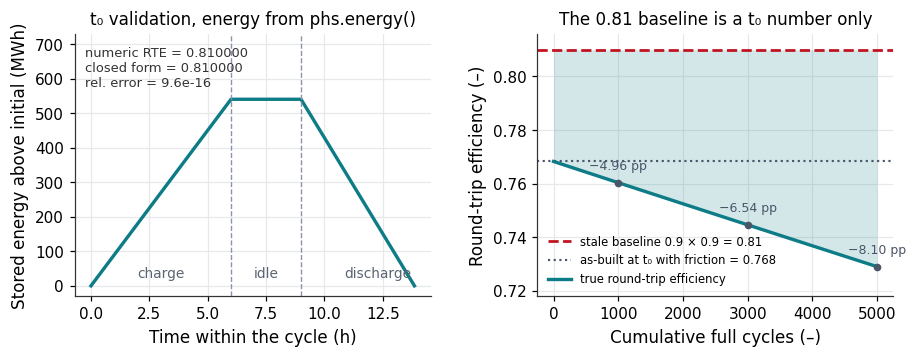

saved fig/f_otwin01_hydro.png


'fig/f_otwin01_hydro.png'

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.1)); fig.subplots_adjust(wspace=0.30)

ax = axes[0]
ax.plot(v0["trace_t_h"], v0["trace_E_MWh"], "-", color=TEAL, lw=2.2)
for x in (T_CHG/3600, (T_CHG+T_IDLE)/3600): ax.axvline(x, color="#8A94A6", ls="--", lw=0.9)
ax.text(3.0, 25, "charge", ha="center", fontsize=9, color="#5A6472")
ax.text(7.5, 25, "idle", ha="center", fontsize=9, color="#5A6472")
ax.text(12.3, 25, "discharge", ha="center", fontsize=9, color="#5A6472")
ax.text(0.03, 0.95, "numeric RTE = %.6f\nclosed form = 0.810000\nrel. error = %.1e"
        % (v0["RTE"], abs(v0["RTE"]-closed)/closed), transform=ax.transAxes, va="top",
        fontsize=8.5, color="#333")
ax.set_xlabel("Time within the cycle (h)"); ax.set_ylabel("Stored energy above initial (MWh)")
ax.set_title("t₀ validation, energy from phs.energy()", fontsize=11); ax.set_ylim(-30, 730)
despine(ax)

ax = axes[1]
ax.fill_between(Ns, rte, closed, color=TEAL, alpha=BAND_ALPHA, lw=0)
ax.axhline(closed, color=RED, ls="--", lw=1.8, label="stale baseline 0.9 × 0.9 = 0.81")
ax.axhline(rte0, color=SLATE, ls=":", lw=1.4, label="as-built at t₀ with friction = %.3f" % rte0)
ax.plot(Ns, rte, "-", color=TEAL, lw=2.2, label="true round-trip efficiency")
for N in (1000, 3000, 5000):
    ax.plot([N], [at(N)], "o", color=SLATE, ms=4, zorder=6)
    ax.annotate("−%.2f pp" % (100*(closed-at(N))), xy=(N, at(N)), xytext=(N, at(N)+0.005),
                fontsize=8.2, color=SLATE, ha="center")
ax.set_xlabel("Cumulative full cycles (–)"); ax.set_ylabel("Round-trip efficiency (–)")
ax.set_title("The 0.81 baseline is a t₀ number only", fontsize=11)
ax.legend(frameon=False, fontsize=7.6, loc="lower left"); ax.set_ylim(0.718, 0.816)
despine(ax)
save(fig, "f_otwin01_hydro")

## 7 · Change one thing

- **Break the structure.** Set `C1 = -0.02` in section 1 and re-run section 2. `R_psd` fails with
  a negative margin; then run section 3 and watch energy *grow* during "spin-down". The check is
  not decoration.
- **Loosen the integrator.** In section 3 change `solve_ivp(..., rtol=1e-12)` to `rtol=1e-3`.
  The general-purpose integrator drifts; `integrate_phs` on the same grid does not.
- **Close the port.** In section 5 return `np.array([0.0])` from the port law: the reservoir
  should sit still to machine precision.

In [11]:
# Try it: a flywheel with the wrong sign on its bearing loss.
bad = PortHamiltonianSystem(
    H=lambda x: x[0]**2/(2*I_fw), grad_H=lambda x: np.array([x[0]/I_fw]),
    J=lambda x: np.zeros((1, 1)), R=lambda x: np.array([[-0.02]]),   # <- negative "friction"
    g=lambda x: np.array([[1.0]]), n_states=1, n_inputs=1)
print("structure:", bad.check_structure(np.array([I_fw*700.0])))
tb = np.linspace(0, 600, 601)
sb = integrate_phs(bad, np.array([I_fw*700.0]), tb, np.zeros((len(tb), 1)))
Hb = np.array([bad.energy(x) for x in sb["x"]])
print("energy over 10 min with the ports closed: %.3f MJ -> %.3f MJ" % (Hb[0]/1e6, Hb[-1]/1e6))


structure: {'J_skew': (np.True_, 0.0), 'R_psd': (False, -0.02)}
energy over 10 min with the ports closed: 294.000 MJ -> 299.939 MJ


## What you learned

- Four functions — `H`, `J`, `R`, `g` — are a complete physical model, and otwin checks the two
  properties that make it one.
- "Positive semi-definite" is the test; a rank-one `R` with a zero eigenvalue is correct physics.
- With the ports closed, energy cannot rise. You can watch it not rise, step by step.
- A machine holding rated power is a port law `u(t, x)`, three lines long.
- A number validated at commissioning is a number about commissioning.

**Next:** [notebook 02](otwin_02_iphs_reactor.ipynb) — when the process produces entropy, and
what changes.

---
*For CI, not for you.* The cells below assert this notebook still reproduces the original
study's numbers.

In [12]:
# Headline numbers: computed in THIS notebook against the value recorded in the
# original notebook series (results_experiments.json).
REFERENCE = [
    ("X4 hydro max |J+Jᵀ|",                 float(hyd_struct["max_abs_J_plus_JT"]), 0.0,                1e-12),
    ("X4 flywheel min eig(R) (N m s)",      float(fw_struct["min_eigenvalue_of_R"]), 0.02,              2e-2),
    ("X4 hydro numeric RTE",                float(hyd_rt["numeric_RTE"]),            0.8099999999999993, 2e-2),
    ("X4 flywheel numeric RTE",             float(fw_rt["numeric_RTE"]),             0.6969408118700858, 2e-2),
    ("X4 flywheel self-discharge 2 h (%)",  float(fw_free_run["self_discharge_over_2h_pct"]), 93.13302717692757, 2e-2),
    ("E8 numeric RTE at t0",                float(v0["RTE"]),                        0.8100000000000008, 2e-2),
    ("E8 self-discharge over 3 h (frac)",   float(v0["self_discharge_frac_3h"]),     0.0,                1e-9),
    ("E8 gap vs 0.81 at 3000 cycles (pp)",  float(div[3000]["gap_vs_0p81_pp"]),      6.536587845243346,  2e-2),
    ("E8 ageing-only gap at 3000 (pp)",     float(div[3000]["gap_vs_as_built_pp"]),  2.365240128920054,  2e-2),
    ("E8 annual shortfall at 3000 (MWh)",   float(sh3000),                           9951.129715037212,  2e-2),
]
print(f"{'quantity':<52} {'this run':>14}  {'reference':>14}  {'match':>6}")
print("-"*94)
_bad = []
for name, got, ref, tol in REFERENCE:
    if isinstance(got, float) and isinstance(ref, float):
        ok = abs(got-ref) <= max(1e-12, tol*max(abs(ref), 1e-12))
        shown = f"{got:>14.6g}  {ref:>14.6g}"
    else:
        ok = (got == ref); shown = f"{str(got):>14}  {str(ref):>14}"
    print(f"{name:<52} {shown}  {'yes' if ok else 'NO':>6}")
    if not ok: _bad.append(name)
print()
print("all headline numbers reproduced through the otwin API" if not _bad else f"DRIFTED: {_bad}")


quantity                                                   this run       reference   match
----------------------------------------------------------------------------------------------
X4 hydro max |J+Jᵀ|                                               0               0     yes
X4 flywheel min eig(R) (N m s)                                 0.02            0.02     yes
X4 hydro numeric RTE                                           0.81            0.81     yes
X4 flywheel numeric RTE                                    0.696941        0.696941     yes
X4 flywheel self-discharge 2 h (%)                           93.133          93.133     yes
E8 numeric RTE at t0                                           0.81            0.81     yes
E8 self-discharge over 3 h (frac)                                 0               0     yes
E8 gap vs 0.81 at 3000 cycles (pp)                          6.53659         6.53659     yes
E8 ageing-only gap at 3000 (pp)                             2.36524         2

In [13]:
# Regression test. Fails loudly if a headline number has drifted.
assert not _bad, f"headline numbers drifted from the original notebooks: {_bad}"
print("regression test passed")


regression test passed
